

<center><font size=10>Generative AI for Business Applications</center></font>
<center><font size=6>Embeddings to Transformers </center></font>

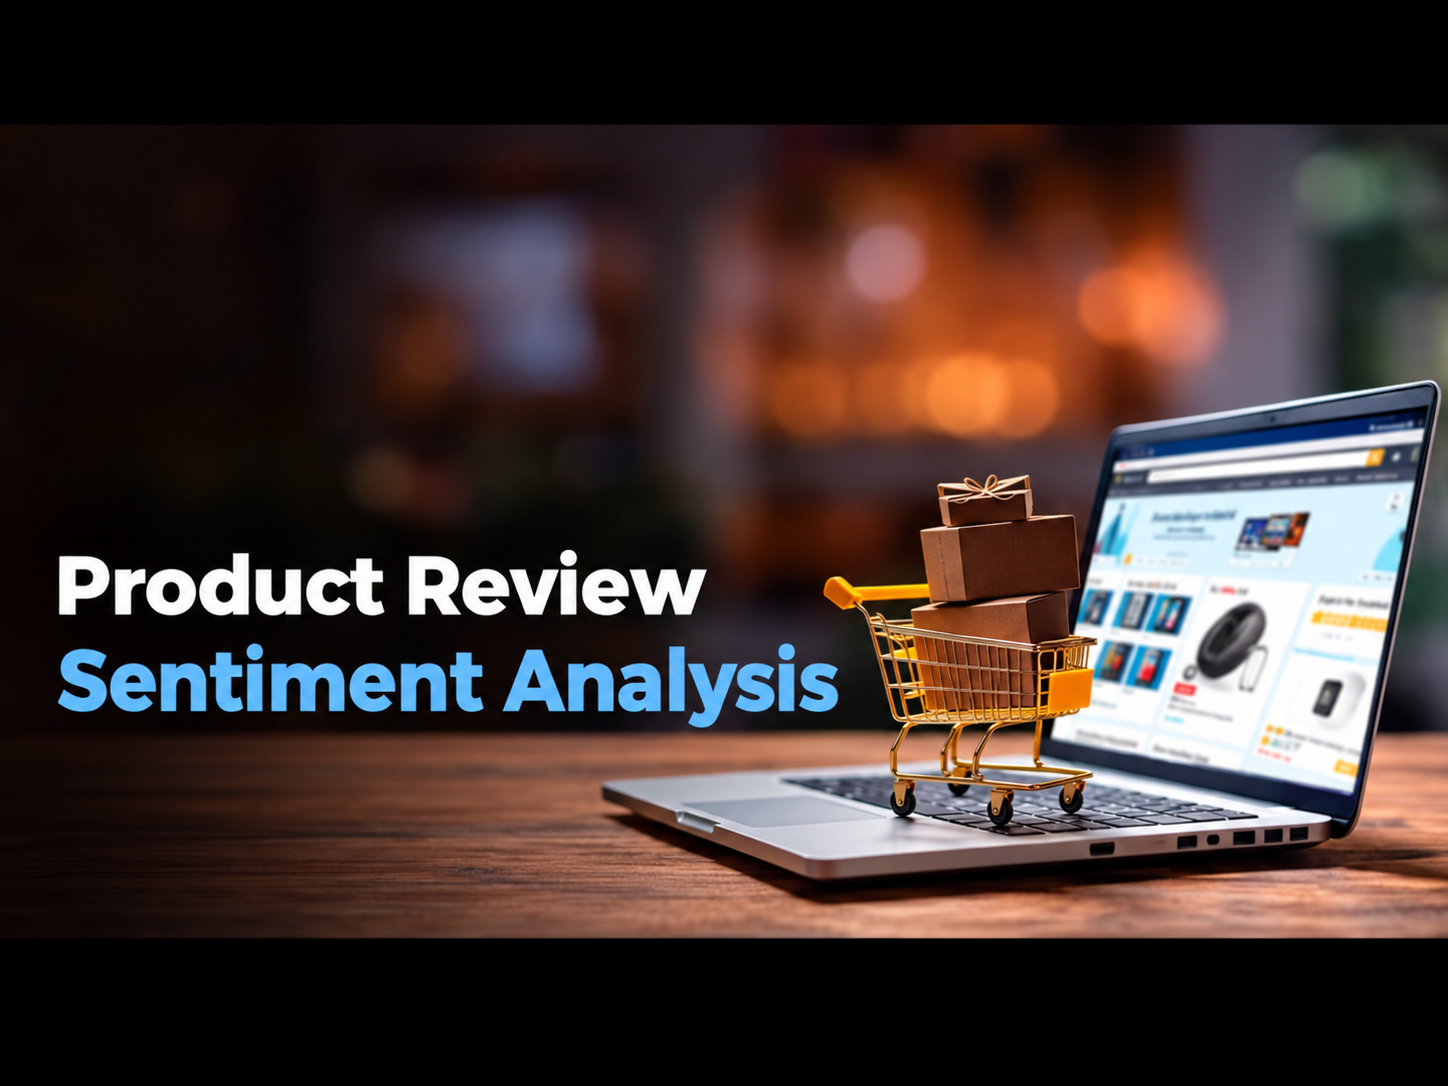

# **Introduction**

## Customer reviews contain useful information about how customers feel about a product. In this project, we use **Sentiment Analysis with Sentence Transformers** to analyze product reviews and classify them into **Positive, Neutral, and Negative** sentiments. This helps businesses understand customer feedback more easily and identify areas for improvement.


### **What this notebook covers, in order:**
1. Loading and inspecting the raw product review dataset.
2. Cleaning the data (checking for missing values and duplicates).
3. Exploring the class balance of the sentiment labels (EDA).
4. Converting each review into a fixed-length numeric embedding using a pre-trained Sentence Transformer.
5. Splitting the embedded data into training and testing sets.
6. Training and evaluating a Random Forest classifier.
7. Training and evaluating a Gradient Boosting classifier.
8. Comparing both models and selecting the better one for deployment.
9. Summarizing findings and outlining next steps.


# **Problem Statement**

## **Business Context**

### Businesses receive many customer reviews about their products and services. Analyzing these reviews helps understand customer satisfaction, identify problems, and improve products. This project uses sentiment analysis to make customer feedback easier to understand.

## **Objective**



### The objective of this project is to develop a sentiment analysis system that can classify product reviews into **Positive, Neutral, and Negative** categories using **Sentence Transformers**. The system helps analyze customer feedback efficiently and understand customer satisfaction. It also helps identify positive aspects of products, detect negative feedback and product issues, and understand neutral reviews that may indicate areas for improvement. The overall goal is to support businesses in making better decisions based on customer feedback.


## Approach / Methodology

### To meet this objective, the notebook follows a standard applied-ML workflow adapted for text data:

### - **Data preparation**: load the review dataset, check its shape, and remove any missing or duplicate records so that the models are trained on clean, non-redundant data.
### - **Exploratory Data Analysis (EDA)**: visualize how the three sentiment classes are distributed, since class imbalance directly affects which evaluation metrics are meaningful and how the models should be assessed.
### - **Feature engineering via Transformers**: instead of hand-crafted text features, use a pre-trained SentenceTransformer to convert every review into a dense semantic embedding vector.
### - **Train/test split**: hold out 20% of the data (stratified by sentiment) purely for unbiased evaluation.
### - **Model building**: train two tree-based ensemble classifiers — Random Forest and Gradient Boosting — on the embeddings.
### - **Model evaluation**: compare both models on training and test accuracy/F1-score to check for overfitting and select the model that generalizes best.
### - **Conclusion**: summarize the results and recommend a final model along with next steps for improvement.


# **Data Description**

## - **Product ID**: An exclusive identification number for each product

## - **Product Review**: Insights and opinions shared by customers about the product

## - **Sentiment**: Sentiment associated with the product review, indicating whether the review expresses a positive, negative, or neutral sentiment

# **Installing Required Libraries**

**Objective:** Install the `sentence-transformers` library, which provides easy access to pre-trained Transformer models that convert text into dense embedding vectors. This library also pulls in its dependencies (`transformers`, `torch`, `scikit-learn`, etc.) needed later in the notebook.

In [ ]:
!pip install sentence-transformers

# **Importing the necessary libraries**

**Objective:** Import all the Python libraries required for the rest of the workflow: `pandas`/`numpy` for data handling, `SentenceTransformer` for generating text embeddings, `train_test_split` for creating train/test partitions, `RandomForestClassifier` and `GradientBoostingClassifier` as the two candidate models, `classification_report`/`accuracy_score` for evaluation, and the `warnings` module to suppress non-critical warning messages for a cleaner notebook output.

In [ ]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

# **Loading the dataset**

## Mount the Google Drive


We use this code to connect Google Drive with Google Colab. After connecting, we can easily access our dataset, images, and project files stored in Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Read the `Product_Reviews.csv` file from the mounted Drive folder into a pandas DataFrame named `data`, which will be the single source of truth for all subsequent steps.

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Gen AI-placement/Product_Reviews.csv")

# **Data Overview**

### Check the overall size of the dataset

In [ ]:
data.shape

(1007, 3)

* The dataset has 1007 rows and 3 columns.

### Preview the first five records of the dataset to visually confirm the columns present (`Product ID`, `Product Review`, `Sentiment`) and get a qualitative feel for the review text and label format.

In [ ]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


### Count missing values in each column to determine whether any imputation or row removal is needed before modeling.

In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* There are no missing values in the data

### Check for duplicate rows in the dataset, since repeated reviews could bias both the class distribution and the train/test split.

In [ ]:
data.duplicated().sum()

np.int64(2)

* There are 2 duplicate values in the dataset.
* We'll drop them.

### Remove the duplicate rows identified above and confirm that none remain, ensuring every record in the training data represents a unique review.

In [ ]:
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

### Reset the DataFrame's row index after dropping duplicates so that indices remain continuous (0, 1, 2, ...) with no gaps, which avoids alignment issues in later steps such as train/test splitting.

In [ ]:
data = data.reset_index(drop=True)

# **Exploratory Data Analysis (EDA)**


### Visualize the distribution of the three sentiment classes (`Positive`, `Neutral`, `Negative`) to understand whether the dataset is balanced or skewed — an important consideration since class imbalance affects both model training and the choice of evaluation metric.

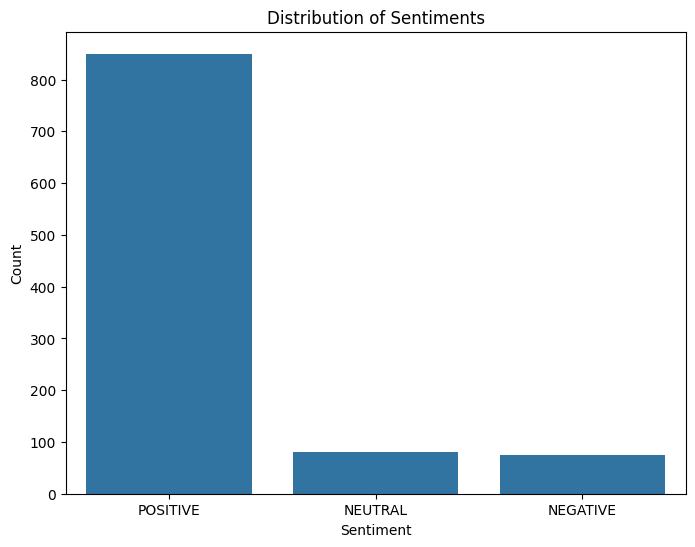

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**
- The dataset contains a majority of positive reviews (\~850), with neutral and negative reviews being significantly fewer, around 75 each.


# **Defining the Sentence Transformer  Model**

### Load the pre-trained `all-MiniLM-L6-v2` SentenceTransformer model. This lightweight Transformer model maps any input sentence to a 384-dimensional dense vector that captures its semantic meaning, and is a popular choice for downstream classification tasks because of its strong accuracy-to-speed tradeoff.

In [ ]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Generate a semantic embedding for every review in the `Product Review` column. This is done in two steps: first confirm the column's data type to make sure it can be safely converted to a list of strings, then pass that list through the SentenceTransformer's `encode` method to produce the embedding matrix.

In [ ]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Every review has now been converted from raw text into a fixed-length numeric vector. These embeddings numerically encode the semantic content of each review and will serve as the input features (`X`) for the machine learning models.

### Verify the shape of the resulting `embedding_matrix` to confirm that every review received an embedding and that the embedding dimensionality matches what is expected from the chosen Transformer model.

In [ ]:
embedding_matrix.shape

(1005, 384)

# **Data Pre-processing**

## Splitting the dataset

### Split the embeddings (`X`) and sentiment labels (`y`) into training and testing sets using an 80:20 ratio. Stratified sampling on `y` is used so that the proportion of positive, neutral, and negative reviews is preserved in both the training and testing sets — important given the class imbalance observed during EDA.

In [ ]:
X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

### Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test` to confirm the split was applied correctly and that the number of samples and features are consistent across the training and testing sets.

In [ ]:
print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


The printed shapes confirm an 80:20 split was applied correctly, with matching sample counts between the feature matrices and their corresponding label vectors.

# **Model Building - Transformers + ML**

### **Model Evaluation Criteria**

1. **Accuracy** is used to measure the overall correctness of the model by calculating the proportion of total correct predictions across all sentiment classes.

2. **F1 Score** is used to evaluate the balance between precision and recall, providing a more reliable performance metric, especially in the presence of class imbalance among positive, neutral, and negative sentiments.


### Create an empty results table, `model_eval_results`, with columns for the model name and its training/testing accuracy and F1-score. This table will be populated as each model is evaluated, making it easy to compare all models side by side at the end.

In [ ]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

# **Random Forest Classifier**

### Train a Random Forest classifier — an ensemble of decision trees — on the training embeddings (`X_train`, `y_train`) to learn the mapping from review embeddings to sentiment labels.

In [ ]:
rf_transformer = RandomForestClassifier(random_state = 42)

rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluate the trained Random Forest model on both the training and testing sets using accuracy and weighted F1-score, then append these metrics as a new row in `model_eval_results` for later comparison.

In [ ]:
from sklearn.metrics import f1_score

y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


The RandomForest model with Transformer embeddings achieved full training accuracy and F1 score, and performed well on the test set with 86.5% accuracy and an F1 score of 81.8%, indicating good generalization.


# **Gradient Boost Classifier**


### Train a Gradient Boosting classifier — an ensemble method that builds trees sequentially, each correcting the errors of the previous one — on the same training embeddings, to compare its performance against the Random Forest model.

In [ ]:
gb_transformer = GradientBoostingClassifier(random_state = 42)

gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

### Evaluate the trained Gradient Boosting model on both the training and testing sets using accuracy and weighted F1-score, then append these metrics as a new row in `model_eval_results` so both models can be compared directly.

In [ ]:
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


The GradientBoost model with Transformer embeddings achieved good training metrics and delivered a test accuracy of 84.07% with an F1 score of 80.3%, indicating slightly lower performance compared to the Random Forest model.


**Note:**
The performance of the classification model can be further improved by exploring additional machine learning techniques and advanced deep learning architectures, such as XGBoost, Support Vector Machines, Sequential neural networks, or fine-tuned transformer-based models.


# **Final Model Selection**


* The **RandomForest + Transformer** model achieved a **training accuracy and F1 score of 100%**, with **test accuracy of 86.6%** and **F1 score of 81.8%**, reflecting a generalization drop of **13.4% in accuracy** and **18.2% in F1 score**.

* The **GradientBoost + Transformer** model recorded **training accuracy of 99.88%** and **F1 score of 99.87%**, but a slightly lower **test accuracy of 84.1%** and **F1 score of 80.3%**, resulting in a generalization drop of **15.8% in accuracy** and **19.6% in F1 score**.

* Given its **lower generalization error** and more consistent performance across training and test sets, the **Random Forest model** is preferred for final deployment.


# **Conclusion**

# **Summary of Work**

This case study built a complete pipeline for classifying product reviews into positive, neutral, and negative sentiment. Raw review text was converted into semantic embeddings using the pre-trained `all-MiniLM-L6-v2` Sentence Transformer, and two ensemble classifiers — Random Forest and Gradient Boosting — were trained on these embeddings and evaluated on a held-out, stratified test set.

## Key Findings

- The dataset (1,007 reviews, reduced to 1,005 after removing 2 duplicates) is **imbalanced**, with roughly 850 positive reviews versus about 75 each for neutral and negative — a factor that makes F1-score a more informative metric than accuracy alone.
- Transformer-based sentence embeddings provided an effective, semantically rich feature representation without requiring manual feature engineering.
- The **Random Forest + Transformer** model reached 100% training accuracy/F1 but generalized to **86.5% test accuracy** and an **81.8% test F1-score**.
- The **Gradient Boosting + Transformer** model reached similarly high training performance (~99.9%) but generalized slightly worse, to **84.1% test accuracy** and an **80.3% test F1-score**.
- Both models show a noticeable gap between training and test performance, indicating some degree of overfitting that is common when a small, imbalanced dataset is paired with high-capacity ensemble models.

# **Model Comparison**

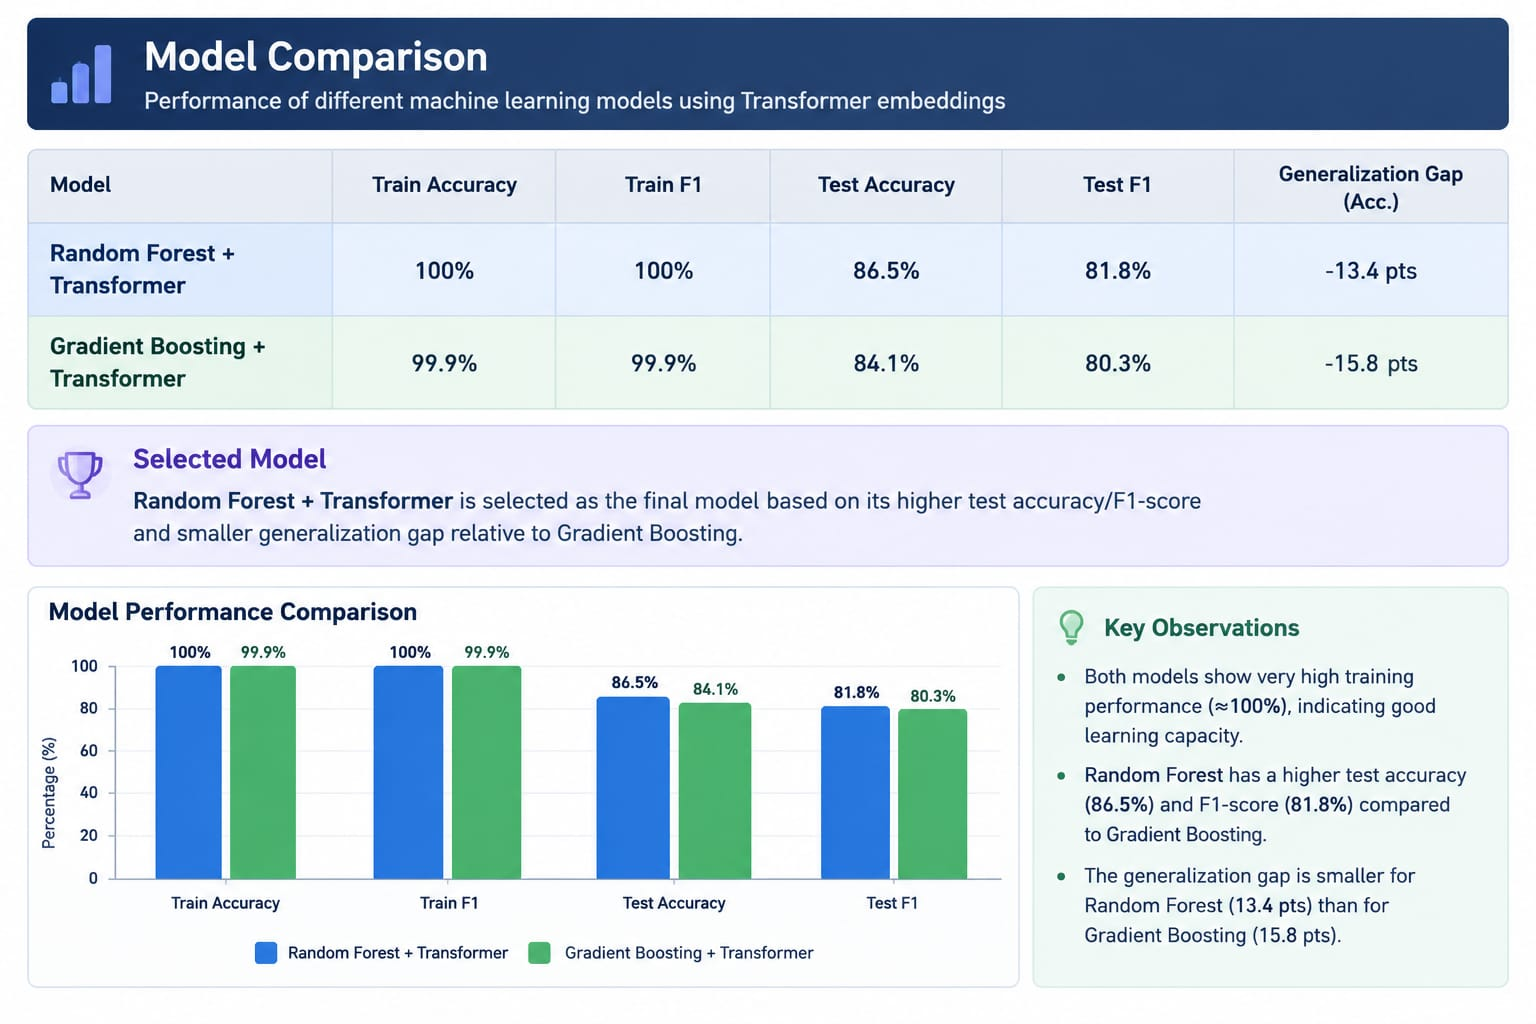

# **Business Recommendations**

- **Deploy the Random Forest + Transformer pipeline** as the initial production sentiment classifier, since it offers the best balance of accuracy and generalization among the models tested.
- **Route negative and neutral predictions to a review queue** for the customer service and product teams, since these classes are under-represented and carry the highest business risk if misclassified.
- **Track model performance over time** as new reviews arrive, since customer language and product mix can shift, and periodically retrain the model to keep it current.
- **Use aggregated sentiment trends** (e.g., week-over-week share of negative reviews per product) to feed product-development and quality-assurance dashboards.

# **Limitations**

- The dataset is **small and imbalanced**, particularly for the neutral and negative classes, which limits how well the models can learn the boundaries of those categories and increases the risk of overfitting.
- Both models show a **noticeable train/test performance gap**, suggesting the current models are somewhat overfit to the training data.
- Only two classical ensemble models were evaluated; more sophisticated approaches were not explored in this notebook.

# **Future Work**

- Address class imbalance using techniques such as class-weighting, oversampling (e.g., SMOTE on embeddings), or collecting more neutral/negative examples.
- Experiment with additional algorithms such as **XGBoost**, **Support Vector Machines**, or a **fully fine-tuned Transformer classifier** (e.g., fine-tuning a BERT-family model end-to-end on this labeled data).
- Perform hyperparameter tuning (e.g., grid search or Bayesian optimization) on the Random Forest model to reduce the training/test performance gap.
- Incorporate new incoming reviews into the training pipeline on a regular cadence so the model adapts to evolving customer language and emerging product issues.

<font size=6 color= 'pink'>Power Ahead</font>
___